# Human Activity Recongnition
Human Activity Recognition (HAR) uses machine learning and sensors (wearables, smartphones, cameras) to identify human actions like walking, falling, or cooking. It is crucial for healthcare monitoring, security, and human-computer interaction. Approaches include sensor-based (inertial data) and vision-based (video/image) techniques to classify daily activities.

<img src="https://explore.research.ufl.edu/wp-content/uploads/2021/03/HAR-abstract-1024x374.png" style="width:70%; height:auto;">

## Key Aspects of Human Activity Recognition:
### Approaches:
* **Sensor-based HAR**: Uses inertial sensors like accelerometers and gyroscopes on devices (e.g., smartphones, wearables) to collect motion data.
* **Vision-based HAR**: Analyzes video sequences or images using techniques like convolutional neural networks (CNNs) to recognize actions, often for surveillance and smart cities.
### Core Methodologies:
* **Machine Learning/Deep Learning**: Models like deep neural networks (DNN) are often used for analyzing temporal data from sensors.
* **Data Processing**: Involves data capturing, preprocessing, and feature extraction to accurately classify activities.
### Applications:
* **Healthcare**: Monitoring elderly patients, fall detection, and physical rehabilitation.
* **Security**: Surveillance systems to detect anomalies or dangerous behaviors in public places.
* **Intelligent Systems**: Human-computer interaction, sports training, and activity tracking in smart homes.

This Human Activity Recognition (HAR) example is based on accelerometer data and TinyML enables on-device, real-time activity classification on resource-constrained microcontrollers. It uses 3-axis ($x$, $y$, $z$) sensor data, optimized through TinyML techniques like pruning and quantization to drastically reduce model size and energy consumption. This technique compress deep learning models to fit in memory.

In [1]:
# Read sample data from a csv file
import pandas as pd

# Load the motion data from the CSV file into a DataFrame
clockwise_motion_df = pd.read_csv('data/clockwise.csv')
horizontal_motion_df = pd.read_csv('data/horizontal.csv')
vertical_motion_df = pd.read_csv('data/vertical.csv')
idle_motion_df = pd.read_csv('data/idle.csv')

# Display the first few rows of each DataFrame to verify the data
print("Clockwise Motion Data:")
print(clockwise_motion_df.head())
print("\nHorizontal Motion Data:")
print(horizontal_motion_df.head())
print("\nVertical Motion Data:")
print(vertical_motion_df.head())
print("\nIdle Motion Data:")
print(idle_motion_df.head())

Clockwise Motion Data:
   timestamp      accX      accY      accZ     motion
0          0  0.645237 -2.387019  5.018247  clockwise
1         10  0.905008 -2.613271  4.495114  clockwise
2         20  1.140837 -2.531868  3.961207  clockwise
3         30  1.284489 -2.261323  3.551798  clockwise
4         40  1.408988 -1.845930  3.256114  clockwise

Horizontal Motion Data:
   timestamp      accX      accY      accZ      motion
0          0 -0.007183  1.606509  9.397242  horizontal
1         10  0.053870  1.697489  8.623915  horizontal
2         20 -0.132878  2.416947  7.352593  horizontal
3         30 -0.378284  3.564966  6.181829  horizontal
4         40 -0.602142  4.510676  5.237316  horizontal

Vertical Motion Data:
   timestamp      accX      accY       accZ    motion
0          0 -0.549469 -0.063446   8.358158  vertical
1         10 -0.877475 -0.560243   9.151836  vertical
2         20 -1.200692 -0.840365   9.701305  vertical
3         30 -1.406593 -0.982820  10.313024  vertical
4    

The **Arduino Nano 33 BLE Sense Rev2** uses the **BMI270** 6-axis IMU (replacing the LSM9DS1 in Rev1), providing 3-axis accelerometer data. It measures acceleration, gyroscope, and magnetic data (via BMM150) with 16-bit resolution, typically accessed using the **Arduino_BMI270_BMM150 library**.

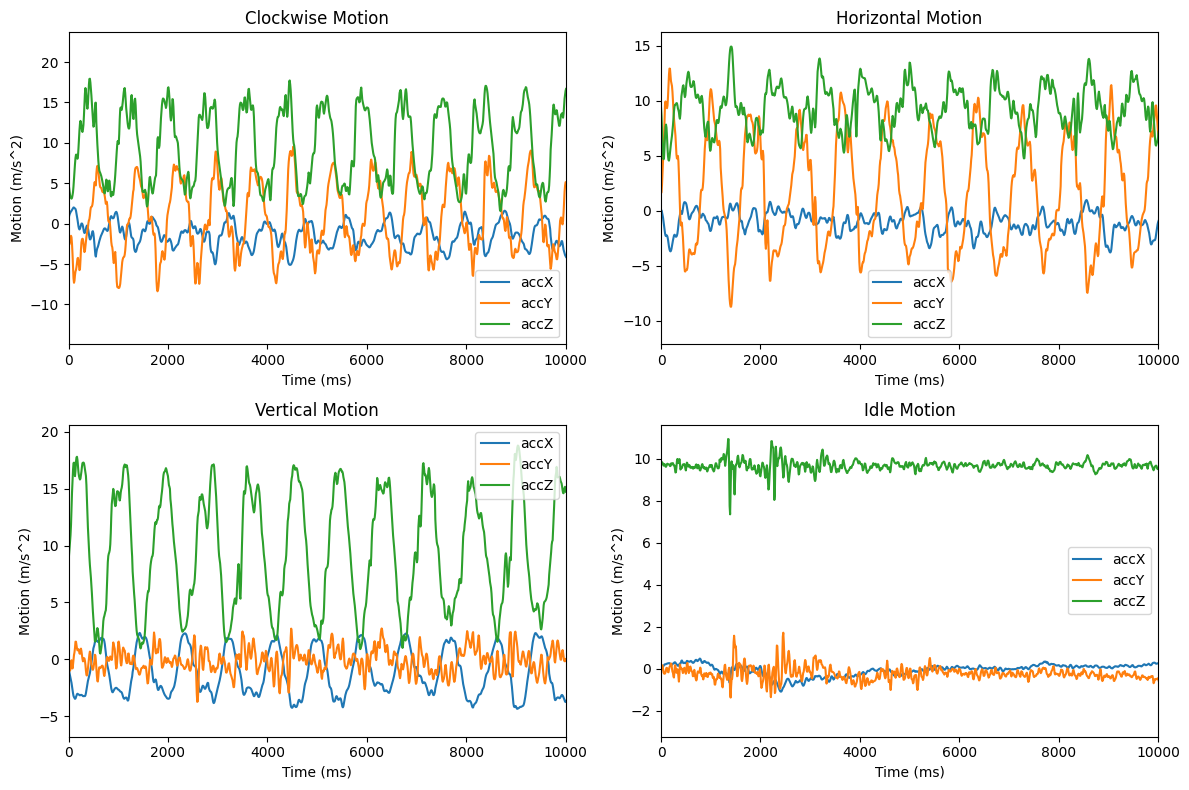

In [2]:
# Plotting the vertical motion data
import matplotlib.pyplot as plt

# Plot motion data with 2 x 2 subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0, 0].plot(clockwise_motion_df['timestamp'], clockwise_motion_df.drop(columns=['timestamp', 'motion']))
axs[0, 0].set_title('Clockwise Motion')
axs[0, 0].set_xlabel('Time (ms)')
axs[0, 0].set_ylabel('Motion (m/s^2)')
axs[0, 0].legend(clockwise_motion_df.drop(columns=['timestamp', 'motion']).columns)
axs[0, 0].set_xlim(0, 10000)
axs[0, 1].plot(horizontal_motion_df['timestamp'], horizontal_motion_df.drop(columns=['timestamp', 'motion']))
axs[0, 1].set_title('Horizontal Motion')
axs[0, 1].set_xlabel('Time (ms)')
axs[0, 1].set_ylabel('Motion (m/s^2)')
axs[0, 1].legend(horizontal_motion_df.drop(columns=['timestamp', 'motion']).columns)
axs[0, 1].set_xlim(0, 10000)
axs[1, 0].plot(vertical_motion_df['timestamp'], vertical_motion_df.drop(columns=['timestamp', 'motion']))
axs[1, 0].set_title('Vertical Motion')
axs[1, 0].set_xlabel('Time (ms)')
axs[1, 0].set_ylabel('Motion (m/s^2)') 
axs[1, 0].legend(vertical_motion_df.drop(columns=['timestamp', 'motion']).columns)
axs[1, 0].set_xlim(0, 10000)          
axs[1, 1].plot(idle_motion_df['timestamp'], idle_motion_df.drop(columns=['timestamp', 'motion']))
axs[1, 1].set_title('Idle Motion')
axs[1, 1].set_xlabel('Time (ms)')
axs[1, 1].set_ylabel('Motion (m/s^2)')
axs[1, 1].legend(idle_motion_df.drop(columns=['timestamp', 'motion']).columns)
axs[1, 1].set_xlim(0, 10000)
plt.tight_layout()
plt.show()


### Signal Processing: IIR Digital Filter
An **Infinite Impulse Response** (IIR) filter is a type of digital filter that uses feedback to compute outputs based on current/past inputs and previous outputs. Unlike FIR filters, IIR filters have an infinitely long impulse response, offering higher computational efficiency and steeper rolloff with fewer coefficients, but they generally have non-linear phase and potential stability issues.

Applying IIR filters to accelerometer data is highly effective for **removing noise components** due to their computational efficiency. Commonly used for real-time applications, they are often implemented as low-pass filters **to smooth data** requiring few computational resources. 

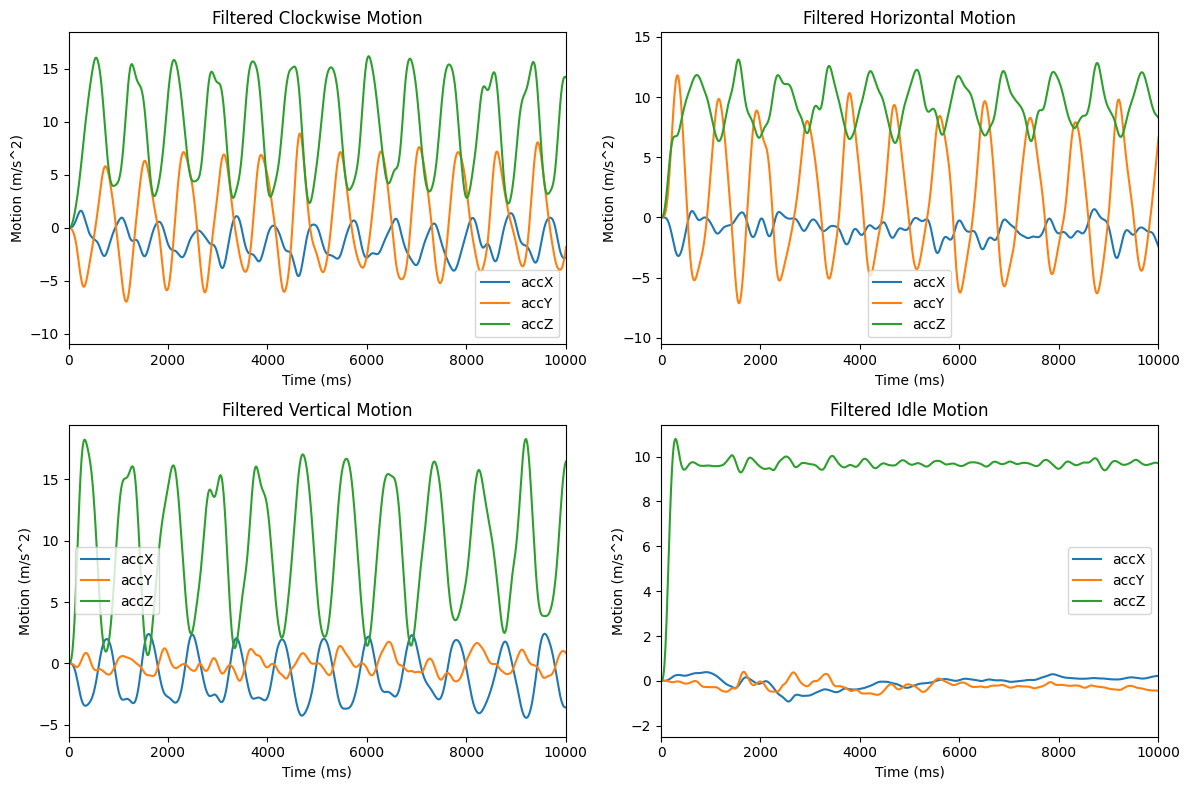

In [3]:
# Design IIR butterworth low-pass filter using scipy signal library
from scipy.signal import butter

# Filter specifications
fs = 100    # Sampling frequency (Hz)
cutoff = 3  # Cutoff frequency (Hz)
order = 4   # Filter order

# Design Butterworth low-pass filter
b, a = butter(order, cutoff, btype='low', fs=fs)

# scipy.signal.sosfilt 
# The scipy.signal.sosfilt function is used to apply a second-order sections (SOS) filter to a signal.
# It is typically used in conjunction with the scipy.signal.butter function when designing IIR filters
# using the 'sos' output option. The sosfilt function takes the SOS coefficients and the input signal, 
# and returns the filtered signal.
from scipy.signal import sosfilt

# Design a low-pass Butterworth filter and get SOS coefficients
sos = butter(order, cutoff, btype='low', fs=fs, output='sos')

# Apply the SOS filter to the motion data
clockwise_motion_filt = sosfilt(sos, clockwise_motion_df.drop(columns=['timestamp', 'motion']).values, axis=0)
horizontal_motion_filt = sosfilt(sos, horizontal_motion_df.drop(columns=['timestamp', 'motion']).values, axis=0)
vertical_motion_filt = sosfilt(sos, vertical_motion_df.drop(columns=['timestamp', 'motion']).values, axis=0)
idle_motion_filt = sosfilt(sos, idle_motion_df.drop(columns=['timestamp', 'motion']).values, axis=0)

# Plot the filtered motion data
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0, 0].plot(clockwise_motion_df['timestamp'], clockwise_motion_filt)
axs[0, 0].set_title('Filtered Clockwise Motion')
axs[0, 0].set_xlabel('Time (ms)')
axs[0, 0].set_ylabel('Motion (m/s^2)')
axs[0, 0].legend(clockwise_motion_df.drop(columns=['timestamp', 'motion']).columns)
axs[0, 0].set_xlim(0, 10000)
axs[0, 1].plot(horizontal_motion_df['timestamp'], horizontal_motion_filt)
axs[0, 1].set_title('Filtered Horizontal Motion')
axs[0, 1].set_xlabel('Time (ms)')
axs[0, 1].set_ylabel('Motion (m/s^2)')
axs[0, 1].legend(horizontal_motion_df.drop(columns=['timestamp', 'motion']).columns)
axs[0, 1].set_xlim(0, 10000)
axs[1, 0].plot(vertical_motion_df['timestamp'], vertical_motion_filt)
axs[1, 0].set_title('Filtered Vertical Motion')
axs[1, 0].set_xlabel('Time (ms)')
axs[1, 0].set_ylabel('Motion (m/s^2)')
axs[1, 0].legend(vertical_motion_df.drop(columns=['timestamp', 'motion']).columns)
axs[1, 0].set_xlim(0, 10000)
axs[1, 1].plot(idle_motion_df['timestamp'], idle_motion_filt)
axs[1, 1].set_title('Filtered Idle Motion')
axs[1, 1].set_xlabel('Time (ms)')
axs[1, 1].set_ylabel('Motion (m/s^2)')
axs[1, 1].legend(idle_motion_df.drop(columns=['timestamp', 'motion']).columns)
axs[1, 1].set_xlim(0, 10000)
plt.tight_layout()
plt.show()


**IIR Butterworth filter** design provides a maximally flat passband response, making it ideal for applications requiring consistent gain. The design process involves calculating the required filter order $N$ based on specifications, finding the digital transfer function, and transforming it into a digital filter using difference equation.

#### General Form of a Digital Transfer Function
The **transfer function** of a digital filter, denoted as $H(z)$, is the $z$-transform of its impulse response, representing the ratio of the output signal $Y(z)$ to the input signal $X(z)$ in the frequency domain.

For a linear time-invariant (LTI) system, the transfer function is expressed as a rational function of $z^{-1}$
$$
H(z)=\frac{Y(z)}{X(z)}=\frac{\sum_{k=0}^{M}b_{k}z^{-k}}{\sum_{j=0}^{N}b_{j}z^{-j}}=\frac{b_{0}+b_{1}z^{-1}+...+b_{M}z^{-M}}{a_{0}+a_{1}z^{-1}+...+a_{N}z^{-N}}
$$

#### General Form of a Difference Equation
A **digital filter's difference equation** is a time-domain formula that computes the **current output** $y[n]$ based on **present inputs** $x[n]$, **past input** $x[n-k]$, and **past outputs** $y[n-j]$. By taking the **inverse z-transform** of the digital tranfer function, the difference equation can be obtain.

The most general form for a linear time-invariant (LTI) digital filter is:
$$
 \sum_{j=0}^{N}a_{k}y[n-j]=\sum_{k=0}^{M}b_{m}x[n-k]
$$





In [40]:
# print the iir filter stages and coefficients values
print("IIR filter stages:")
for i in range(len(sos)):
    print(f"Stage {i+1}: b = {sos[i, :3].astype(float).tolist()}, a = {sos[i, 3:].astype(float).tolist()}")

IIR filter stages:
Stage 1: b = [6.23869835484794e-05, 0.0001247739670969588, 6.23869835484794e-05], a = [1.0, -1.6746609472909773, 0.7048586816622795]
Stage 2: b = [1.0, 2.0, 1.0], a = [1.0, -1.8331252600998054, 0.8661804464426682]


**SOS (Second-Order Section)** coefficients define a digital IIR filter as a cascade of biquad filters, typically organized as an $L * 6$ matrix. Each row contains $b_{0}, b_{1}, b_{2}, a_{0}, a_{1}, a_{2}$, representing the numerator $b$ and denominator $a$ coefficients for that section, providing high numerical stability compared to direct form filters. The ```emlearn``` library uses SOS also known as **biquads** to implement IIR filters, which provides better numerical stability compared to direct-form transfer functions, especially on microcontrollers.

In [4]:
# Generate C++ code for the SOS coefficients to be used in the Arduino implementation
from emlearn import cgen
c_code_array = cgen.array_declare(
    "sos",
    sos.size,
    dtype="float",
    modifiers="const",
    values=sos.flatten().astype(float).tolist(),
)

# Print sos coefficients in Arduino C++ constant array format
print("SOS coefficients C++ array declaration:")
print(c_code_array)

SOS coefficients C++ array declaration:
const float sos[12] = { 0.000062f, 0.000125f, 0.000062f, 1.000000f, -1.674661f, 0.704859f, 1.000000f, 2.000000f, 1.000000f, 1.000000f, -1.833125f, 0.866180f };


### Signal Processing: Sliding Window
**Sliding window** is a signal processing is a technique that analyzes streaming data by computing statistics (e.g., mean, median, RMS) over a fixed-length subset ("window") of data that moves through the signal sample-by-sample. It is crucial for real-time analysis because it updates results based only on new data, rather than recalculating the entire dataset.

The continuous input time-series data is usually transformed into a series of fixed-length feature vectors. Individual features vector for one time-step is often referred to as a **window frame**. Multiple frames are often combined to form a context window, consisting of $N$ frames. This is often referred to as using sliding windows or moving windows, or using a continious classification approach.

<img src="https://emlearn.readthedocs.io/en/latest/_images/event_detection_labels_windows.png" style="width:70%; height:auto;">

The distance between windows is known as the **hop length**. This is normally smaller than the size of the window (window length), so effectively there is a degree of overlap between consecutive windows. The overlap might be as low as $50\%$, or as high as $99\%$. This ensures that the model sees the events during training at multiple different positions inside the window. The use of the sliding window approach in combination with feature engineering makes it possible to use any standard machine learning classifier for event detection.

In [13]:
import numpy as np
from scipy.signal import get_window

# Build a window function for framing the signal
def build_window(window_type='boxcar', length=8, symmetric=False):
    fftbins = not symmetric
    return get_window(window_type, length, fftbins=fftbins).astype(np.float32)

# Create sliding window frames from 1D or multi-axis signals
def sliding_window_frames(signal, window_size, hop_size, window_type='boxcar', symmetric=False):
    if window_size <= 0:
        raise ValueError('window_size must be > 0')
    if hop_size <= 0:
        raise ValueError('hop_size must be > 0')

    signal = np.asarray(signal, dtype=np.float32)
    if signal.ndim == 1:
        signal = signal[:, np.newaxis]
    elif signal.ndim != 2:
        raise ValueError('signal must be 1D or 2D with shape (samples, channels)')

    n_samples, _ = signal.shape
    if n_samples < window_size:
        raise ValueError('signal must be at least as long as window_size')

    window = build_window(window_type=window_type, length=window_size, symmetric=symmetric)
    window_2d = window[:, np.newaxis]
    frame_count = 1 + (n_samples - window_size) // hop_size

    frames = np.stack([
        signal[start:start + window_size, :] * window_2d
        for start in range(0, frame_count * hop_size, hop_size)
    ])
    return frames, window

# Apply sliding window to the filtered motion data
from scipy import signal

# Define sliding window parameters
window_frame_size_ms = 2000
window_frame_stride_ms = 500
window_size_samples = int(window_frame_size_ms * fs / 1000)
window_stride_samples = int(window_frame_stride_ms * fs / 1000)

# Apply sliding window to the filtered motion data
clockwise_motion_windows, clockwise_motion_frames = sliding_window_frames(clockwise_motion_filt, 
                                                                          window_size_samples, 
                                                                          window_stride_samples,
                                                                          window_type='boxcar',
                                                                          symmetric=False)

horizontal_motion_windows, horizontal_motion_frames = sliding_window_frames(horizontal_motion_filt,
                                                                            window_size_samples, 
                                                                            window_stride_samples,
                                                                            window_type='boxcar',
                                                                            symmetric=False)

vertical_motion_windows, vertical_motion_frames = sliding_window_frames(vertical_motion_filt,
                                                                        window_size_samples, 
                                                                        window_stride_samples,
                                                                        window_type='boxcar',
                                                                        symmetric=False)

idle_motion_windows, idle_motion_frames = sliding_window_frames(idle_motion_filt,
                                                                window_size_samples, 
                                                                window_stride_samples,
                                                                window_type='boxcar',
                                                                symmetric=False)

# Print the shapes of the resulting windows
print("Clockwise Motion Windows Shape:", clockwise_motion_windows.shape)
print("Horizontal Motion Windows Shape:", horizontal_motion_windows.shape)
print("Vertical Motion Windows Shape:", vertical_motion_windows.shape)
print("Idle Motion Windows Shape:", idle_motion_windows.shape)

Clockwise Motion Windows Shape: (237, 200, 3)
Horizontal Motion Windows Shape: (237, 200, 3)
Vertical Motion Windows Shape: (237, 200, 3)
Idle Motion Windows Shape: (237, 200, 3)


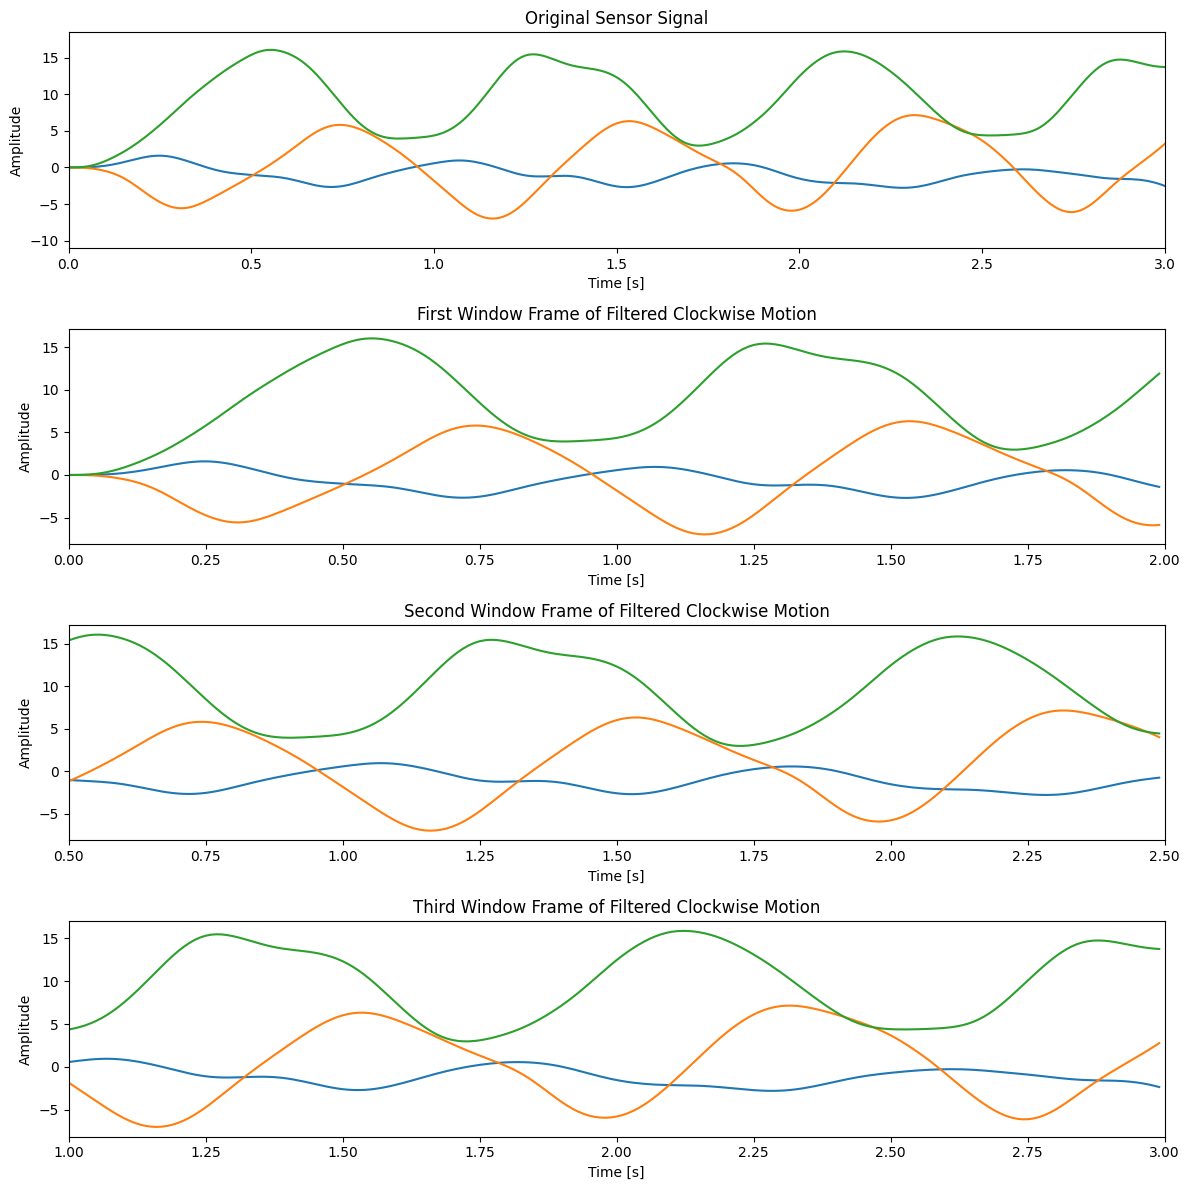

In [35]:
# Plot the first few windows frame of the filtered motion data
plt.figure(figsize=(12, 12))
plt.subplot(4, 1, 1)
plt.plot(np.arange(len(clockwise_motion_filt)) / fs, clockwise_motion_filt, label='Original Signal')
plt.title('Original Sensor Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.xlim(0, 3)
plt.subplot(4, 1, 2)
plt.plot(np.arange(clockwise_motion_windows.shape[1]) / fs, clockwise_motion_windows[0], label='First Window Frame')
plt.title('First Window Frame of Filtered Clockwise Motion')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.xlim(0, 2)
plt.subplot(4, 1, 3)
plt.plot((np.arange(clockwise_motion_windows.shape[1]) + 50) / fs, clockwise_motion_windows[1], label='Second Window Frame')
plt.title('Second Window Frame of Filtered Clockwise Motion')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.xlim(0.5, 2.5)
plt.subplot(4, 1, 4)
plt.plot((np.arange(clockwise_motion_windows.shape[1]) + 100) / fs, clockwise_motion_windows[2], label='Third Window Frame')
plt.title('Third Window Frame of Filtered Clockwise Motion')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.xlim(1.0, 3.0)
plt.tight_layout()
plt.show()

### Signal Processing: Fast Fourier Transform (FFT)
The **Fast Fourier Transform (FFT)** is an efficient algorithm that computes the **Discrete Fourier Transform (DFT)** of a sequence, a mathematical operation that converts a finite sequence of equally spaced signal samples (time domain) into a sequence of complex numbers representing frequency components (frequency domain). It reduces computation time from $O(N^2)$ to $O(N\log(N))$, making real-time processing of audio, image data, and communications possible. It is widely used to analyze the frequency content of discrete signals, with the Fast Fourier Transform (FFT) providing an efficient computational algorithm for it.

<img src="https://miro.medium.com/0*3SPZL7OBkn4RhLkG.gif" style="width:70%; height:auto;">

Discrete Fourier Transform can be expressed as:
$$
X(k) = \sum_{n=0}^{N-1} x(n) e^{-j\frac{2\pi}{N}kn}
$$

```emlearn``` provides a FFT implementation designed specifically for efficient signal processing on microcontrollers and embedded systems. It is primarily used to extract frequency-domain features from raw sensor data, such as audio or vibration, before passing them to machine learning models for tasks like event detection or sound classification. Implemented in clean C99 code, making it compatible with a wide range of hardware, including Arduino, STM32 (ARM Cortex M), ESP32, and even 8-bit AVR microcontrollers.

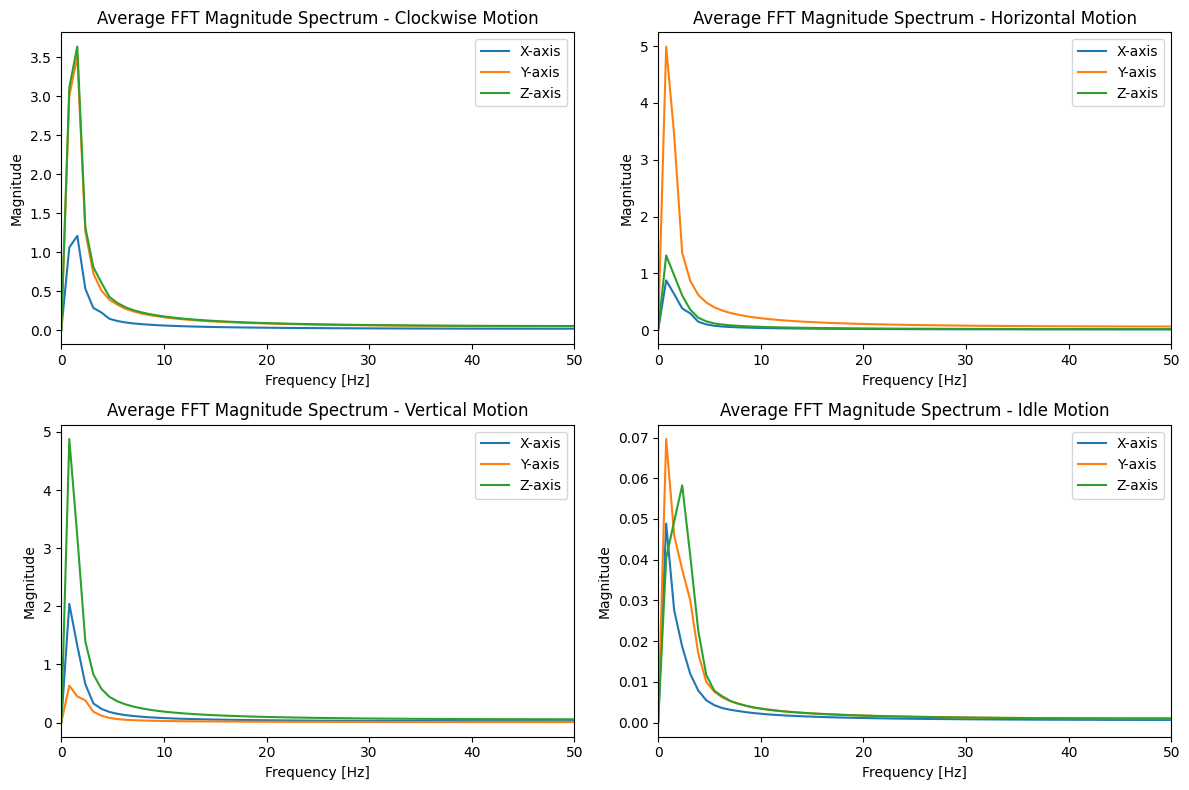

In [42]:
N = 128     # Define the number of samples to use for FFT analysis
fs = 100    # Sampling frequency in Hz (100 samples per second)

# Preprocess to emphasize motion frequencies over DC offset using boxcar window and mean subtraction
boxcar_window = np.ones(N, dtype=np.float32)

# Match FFT length to available window length and keep all classes consistent
if N > clockwise_motion_windows.shape[1]:
    raise ValueError(f"N={N} is larger than window length {clockwise_motion_windows.shape[1]}")

# Truncate the windows to ensure they all have the same length N for FFT analysis
clockwise_motion_windows = clockwise_motion_windows[:, :N, :]
horizontal_motion_windows = horizontal_motion_windows[:, :N, :]
vertical_motion_windows = vertical_motion_windows[:, :N, :]
idle_motion_windows = idle_motion_windows[:, :N, :]

# Apply mean subtraction (per window, per axis) and windowing to the motion data
clockwise_motion_windowed_sig = (clockwise_motion_windows - clockwise_motion_windows.mean(axis=1, keepdims=True)) * boxcar_window[None, :, None]
horizontal_motion_windowed_sig = (horizontal_motion_windows - horizontal_motion_windows.mean(axis=1, keepdims=True)) * boxcar_window[None, :, None]
vertical_motion_windowed_sig = (vertical_motion_windows - vertical_motion_windows.mean(axis=1, keepdims=True)) * boxcar_window[None, :, None]
idle_motion_windowed_sig = (idle_motion_windows - idle_motion_windows.mean(axis=1, keepdims=True)) * boxcar_window[None, :, None]

# Perform FFT analysis on the windowed motion data
from scipy.fft import rfft, rfftfreq

# Compute the FFT for each motion window along the time axis
# Result shape: (n_windows, 65, 3)
clockwise_motion_fft_X = rfft(clockwise_motion_windowed_sig, axis=1)
horizontal_motion_fft_X = rfft(horizontal_motion_windowed_sig, axis=1)
vertical_motion_fft_X = rfft(vertical_motion_windowed_sig, axis=1)
idle_motion_fft_X = rfft(idle_motion_windowed_sig, axis=1)

# Compute the corresponding frequencies for the FFT
clockwise_motion_freqs = rfftfreq(N, d=1/fs)
horizontal_motion_freqs = rfftfreq(N, d=1/fs)
vertical_motion_freqs = rfftfreq(N, d=1/fs)
idle_motion_freqs = rfftfreq(N, d=1/fs)

# Keep all FFT frames for feature extraction: (n_windows, 65, 3)
clockwise_motion_fft_mag_frames = 2 * np.abs(clockwise_motion_fft_X) / np.sum(boxcar_window)
horizontal_motion_fft_mag_frames = 2 * np.abs(horizontal_motion_fft_X) / np.sum(boxcar_window)
vertical_motion_fft_mag_frames = 2 * np.abs(vertical_motion_fft_X) / np.sum(boxcar_window)
idle_motion_fft_mag_frames = 2 * np.abs(idle_motion_fft_X) / np.sum(boxcar_window)

# Also keep one averaged spectrum per class for visualization: (65, 3)
clockwise_motion_fft_mag = clockwise_motion_fft_mag_frames.mean(axis=0)
horizontal_motion_fft_mag = horizontal_motion_fft_mag_frames.mean(axis=0)
vertical_motion_fft_mag = vertical_motion_fft_mag_frames.mean(axis=0)
idle_motion_fft_mag = idle_motion_fft_mag_frames.mean(axis=0)

# Plot the average FFT magnitude spectra for each motion class
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(clockwise_motion_freqs, clockwise_motion_fft_mag[:, 0], label='X-axis')
plt.plot(clockwise_motion_freqs, clockwise_motion_fft_mag[:, 1], label='Y-axis')
plt.plot(clockwise_motion_freqs, clockwise_motion_fft_mag[:, 2], label='Z-axis')
plt.title('Average FFT Magnitude Spectrum - Clockwise Motion')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend()
plt.xlim(0, fs/2)
plt.subplot(2, 2, 2)
plt.plot(horizontal_motion_freqs, horizontal_motion_fft_mag[:, 0], label='X-axis')
plt.plot(horizontal_motion_freqs, horizontal_motion_fft_mag[:, 1], label='Y-axis')
plt.plot(horizontal_motion_freqs, horizontal_motion_fft_mag[:, 2], label='Z-axis')
plt.title('Average FFT Magnitude Spectrum - Horizontal Motion')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend()
plt.xlim(0, fs/2)
plt.subplot(2, 2, 3)
plt.plot(vertical_motion_freqs, vertical_motion_fft_mag[:, 0], label='X-axis')
plt.plot(vertical_motion_freqs, vertical_motion_fft_mag[:, 1], label='Y-axis')
plt.plot(vertical_motion_freqs, vertical_motion_fft_mag[:, 2], label='Z-axis')
plt.title('Average FFT Magnitude Spectrum - Vertical Motion')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend()
plt.xlim(0, fs/2)
plt.subplot(2, 2, 4)
plt.plot(idle_motion_freqs, idle_motion_fft_mag[:, 0], label='X-axis')
plt.plot(idle_motion_freqs, idle_motion_fft_mag[:, 1], label='Y-axis')
plt.plot(idle_motion_freqs, idle_motion_fft_mag[:, 2], label='Z-axis')
plt.title('Average FFT Magnitude Spectrum - Idle Motion')   
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.legend()
plt.xlim(0, fs/2)
plt.tight_layout()
plt.show()      

### Signal Processing: Features Extraction
**Feature engineering** is the process of using domain knowledge to extract, transform, and select variables (features) from raw data to improve machine learning model performance. It involves creating new, more informative inputs, handling categorical data, and scaling numerical data to help algorithms learn faster and make more accurate predictions. **Feature extraction** is a critical machine learning process that transforms raw, unstructured data (images, audio, text) into structured, numerical features, reducing complexity while retaining essential information. It enhances model accuracy and computational efficiency by distilling data to relevant patterns, serving as a key subset of feature engineering.

**Spectral features** extracted from Fast Fourier Transform (FFT) convert time-domain signals (e.g., vibration, audio) into the frequency domain, revealing key characteristics like frequency content, amplitude, and energy distribution. These features including fundamental frequency, spectral centroid, and power spectral density (PSD) are critical for tasks such as machine diagnostics, audio analysis, and structural health monitoring.

The following spectral features used in this project are:
* **Spectral Peak**: represents the maximum amplitude within a power spectrum, pinpointing the dominant frequencies (periodicities) in a dataset.
$$
f_{peak}=max(fft_{mag})
$$
* **Spectral Mean**: calculated by taking the FFT of a signal, calculating the magnitude (power) of each frequency component, and then averaging these spectral values over time or across sections of the signal.
$$
f_{mean} = \frac{1}{N} \sum_{i=1}^{N} fft_{mag}(\omega_i)
$$
* **Spectral RMS**: often called the **overall level**, represents the total energy of a signal across a specific frequency range. It is calculated by taking the square root of the sum of the squares of all spectral line amplitudes, providing a single scalar value that indicates total signal intensity.
$$
f_{rms} = \sqrt{\sum_{i=1}^{n} fft_{mean}^2}
$$
* **Power Spectral Density**: represents the distribution of a signal's power (or variance) over a frequency spectrum, typically normalized to a per-hertz ($Hz$) bandwidth. It identifies which frequencies contain strong or weak signal variations.
$$
f_{psd} = \frac{2|fft_{mag}|^2}{f_s N}
$$
* **Spectral Energy**: represent the distribution of a signal's signal strength across frequency bins, calculated by taking the magnitude squared of the FFT result.
$$
f_{energy} = |fft_{mag}|^2
$$
* **Spectral Standard Deviation**: measures the dispersion or variance of frequency components, often indicating signal noise or chaotic behavior.
$$
f_{\sigma} = \sqrt{\frac{\sum_{i=1}^{N} (fft_{mag}(i) - fft_{mean})^2}{N-1}}
$$

In [43]:
# Spectral features extraction from one FFT magnitude vector
# Peak, Mean, RMS, Power Spectral Density (PSD), Energy Spectral Density (ESD), Standard Deviation
def extract_spectral_features(fft_mag, freqs):
    features = {}
    features['peak'] = np.max(fft_mag)
    features['mean'] = np.mean(fft_mag)
    features['rms'] = np.sqrt(np.mean(fft_mag ** 2))
    features['psd'] = np.sum(fft_mag ** 2) / len(fft_mag)
    features['energy'] = np.sum(fft_mag ** 2)
    features['std'] = np.std(fft_mag)
    return features

# Extract spectral features for each window frame and combine into a DataFrame
def extract_window_feature_table(fft_mag_frames, freqs, label):
    rows = []
    axes = ['x', 'y', 'z']
    for window_idx in range(fft_mag_frames.shape[0]):
        row = {
            'label': label,
            'window_index': window_idx,
        }
        for axis_idx, axis_name in enumerate(axes):
            axis_features = extract_spectral_features(fft_mag_frames[window_idx, :, axis_idx], freqs)
            for feature_name, feature_value in axis_features.items():
                row[f'{axis_name}_{feature_name}'] = feature_value
        rows.append(row)
    return pd.DataFrame(rows)

# Extract one feature row per FFT window
clockwise_feature_table = extract_window_feature_table(clockwise_motion_fft_mag_frames, clockwise_motion_freqs, 'clockwise')
horizontal_feature_table = extract_window_feature_table(horizontal_motion_fft_mag_frames, horizontal_motion_freqs, 'horizontal')
vertical_feature_table = extract_window_feature_table(vertical_motion_fft_mag_frames, vertical_motion_freqs, 'vertical')
idle_feature_table = extract_window_feature_table(idle_motion_fft_mag_frames, idle_motion_freqs, 'idle')

# Combine all windows into one training dataset
spectral_feature_dataset = pd.concat([
    clockwise_feature_table,
    horizontal_feature_table,
    vertical_feature_table,
    idle_feature_table,
], ignore_index=True)

# Display random sample of the extracted spectral features dataset
spectral_feature_dataset.sample(10).style.hide(axis='index')

label,window_index,x_peak,x_mean,x_rms,x_psd,x_energy,x_std,y_peak,y_mean,y_rms,y_psd,y_energy,y_std,z_peak,z_mean,z_rms,z_psd,z_energy,z_std
horizontal,226,0.884122,0.074607,0.161412,0.026054,1.693494,0.143135,4.507503,0.376748,0.876606,0.768438,49.948452,0.791517,1.117644,0.090360,0.209970,0.044088,2.865690,0.189533
horizontal,174,0.673815,0.045440,0.125528,0.015757,1.024230,0.117015,4.636350,0.262415,0.762400,0.581253,37.781456,0.715815,1.570980,0.087165,0.280336,0.078588,5.108251,0.266441
idle,217,0.014506,0.000858,0.002575,0.000007,0.000431,0.002428,0.036107,0.002589,0.006029,0.000036,0.002363,0.005445,0.027489,0.002019,0.004675,0.000022,0.001420,0.004216
horizontal,9,0.831765,0.052409,0.141750,0.020093,1.306047,0.131705,5.501153,0.206985,0.776541,0.603017,39.196079,0.748448,2.129542,0.079015,0.309231,0.095624,6.215564,0.298966
idle,199,0.053563,0.003537,0.008626,0.000074,0.004837,0.007868,0.064456,0.003174,0.009768,0.000095,0.006202,0.009238,0.040045,0.002699,0.007171,0.000051,0.003342,0.006644
clockwise,54,1.668408,0.107154,0.267575,0.071597,4.653775,0.245183,3.032084,0.211617,0.559262,0.312774,20.330292,0.517680,3.246479,0.287881,0.655076,0.429125,27.893093,0.588429
clockwise,8,1.466990,0.083430,0.255214,0.065134,4.233722,0.241192,5.011107,0.235636,0.752259,0.565893,36.783035,0.714401,5.536543,0.323550,0.815769,0.665479,43.256165,0.748863
horizontal,59,0.860559,0.043031,0.141206,0.019939,1.296039,0.134489,4.466080,0.294744,0.758080,0.574686,37.354580,0.698435,1.192955,0.075539,0.239443,0.057333,3.726655,0.227216
vertical,191,2.139608,0.137702,0.340550,0.115974,7.538323,0.311468,0.516509,0.052815,0.107871,0.011636,0.756344,0.094057,4.474281,0.269946,0.738595,0.545523,35.458984,0.687497
horizontal,24,0.512641,0.024290,0.093809,0.008800,0.572013,0.090610,4.272694,0.300397,0.743567,0.552892,35.937962,0.680186,1.753362,0.145249,0.307633,0.094638,6.151467,0.271184


### Signal Processing: Features Scaling
The **Standard Scaler** is a data preprocessing technique in machine learning that standardizes features by removing the mean and scaling the data to unit variance. This results in a transformed dataset with a mean of zero and a standard deviation of one for each feature.

The formula for the standard score (also known as the z-score) is described below:
$$
z=\frac{x-\mu}{  \sigma}
$$

Where
* $z$ is the scaled, or standardized, value (the z-score).
* $x$ is the original feature value.
* $\mu$ is the mean of the feature's training samples.
* $\sigma$ is the standard deviation of the feature's training samples. 

The primary purpose of the Standard Scaler is to ensure that features with different scales contribute equally to a model's objective function, preventing features with large variances from dominating those with smaller variances.

In [52]:
# Scale the features using StandardScaler
from sklearn.preprocessing import StandardScaler

# Select only the feature columns for scaling
feature_columns = [col for col in spectral_feature_dataset.columns if col not in ['label', 'window_index']]

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the feature columns and transform the data
scaled_spectral_features = scaler.fit_transform(spectral_feature_dataset[feature_columns])

# Create a new DataFrame with the scaled features and the original labels
scaled_spectral_feature_df = pd.DataFrame(scaled_spectral_features, columns=feature_columns)
scaled_spectral_feature_df['label'] = spectral_feature_dataset['label']

# Display random sample of the scaled spectral features dataset
scaled_spectral_feature_df.sample(10).style.hide(axis='index')

x_peak,x_mean,x_rms,x_psd,x_energy,x_std,y_peak,y_mean,y_rms,y_psd,y_energy,y_std,z_peak,z_mean,z_rms,z_psd,z_energy,z_std,label
-1.203606,-1.230660,-1.292120,-1.055047,-1.055047,-1.283863,-1.036041,-0.986417,-1.062958,-0.934406,-0.934406,-1.066086,-1.237464,-1.198748,-1.270410,-1.027814,-1.027814,-1.269239,idle
0.514735,1.559310,1.033018,1.046500,1.046500,0.941367,-0.690523,-0.598628,-0.720238,-0.860950,-0.860950,-0.732484,1.219625,1.797805,1.553938,2.068439,2.068438,1.510215,vertical
-1.405061,-1.370521,-1.459407,-1.065738,-1.065738,-1.453524,-1.124652,-1.094464,-1.148186,-0.938076,-0.938076,-1.146770,-1.268727,-1.233839,-1.303049,-1.028665,-1.028666,-1.301321,idle
-1.326339,-1.303852,-1.384251,-1.063268,-1.063268,-1.377806,-1.092565,-1.063420,-1.112890,-0.937262,-0.937262,-1.110957,-1.228286,-1.214813,-1.266549,-1.027661,-1.027661,-1.262878,idle
-1.387559,-1.352111,-1.443214,-1.065527,-1.065528,-1.437818,-1.115698,-1.079704,-1.139128,-0.937962,-0.937962,-1.138894,-1.249657,-1.226535,-1.290508,-1.028433,-1.028433,-1.288165,idle
0.987628,0.639118,0.965204,0.933620,0.933620,1.007619,-0.666730,-0.782118,-0.769118,-0.877175,-0.877175,-0.760009,1.142291,0.171384,0.897096,0.815057,0.815057,0.985887,vertical
-0.478398,-0.011830,-0.308254,-0.610497,-0.610497,-0.348420,1.619801,0.534342,1.281537,1.446278,1.446278,1.373910,-0.173885,-0.554452,-0.307973,-0.643973,-0.643973,-0.271213,horizontal
-1.097846,-1.193940,-1.205374,-1.042076,-1.042077,-1.191718,-1.014406,-1.011018,-1.028006,-0.931220,-0.931220,-1.022196,-1.225413,-1.200038,-1.250940,-1.026927,-1.026927,-1.247142,idle
-0.596890,-0.866167,-0.685456,-0.858048,-0.858048,-0.652579,1.180581,0.488364,0.919296,0.791083,0.791083,0.976768,-0.400319,-0.525961,-0.328762,-0.659597,-0.659597,-0.297307,horizontal
1.312270,0.916055,1.309384,1.538576,1.538576,1.358032,-0.854787,-0.800682,-0.885087,-0.908017,-0.908017,-0.890055,0.777520,0.855119,0.874119,0.777064,0.777064,0.876400,vertical


#### Signal Processing: Export Scaler Parameters for Arduino
After fitting StandardScaler on the training features, the learned mean and standard deviation values must be exported so the microcontroller can apply the same normalization during inference.

The ```emlearn cgen``` utility is used to convert these parameters into C++ constant arrays, typically named scaler_means and scaler_stds. These arrays are then included in the Arduino project to keep preprocessing consistent between Python training and embedded deployment.

This step prevents feature mismatch and helps maintain model accuracy when running the classifier on-device.

In [ ]:
# Scaler parameters for each feature column to be used in the Arduino implementation
scaler_params = {
    'mean': scaler.mean_.tolist(),
    'std': scaler.scale_.tolist(),  # StandardScaler stores std in scale_
}

# Convert scaler parameters to Arduino C++ arrays using emlearn.cgen
from emlearn import cgen
import textwrap

feature_count = len(feature_columns)
linewrap = 100

mean_array_c = cgen.array_declare(
    "scaler_means",
    feature_count,
    dtype="float",
    modifiers="const",
    values=scaler_params['mean'],
)

std_array_c = cgen.array_declare(
    "scaler_stds",
    feature_count,
    dtype="float",
    modifiers="const",
    values=scaler_params['std'],
)

# Wrap lines like the reference script
features_size_wrapped = "\n".join(textwrap.wrap(f"static constexpr int n_features =  {feature_count};", linewrap))
mean_array_wrapped = "\n".join(textwrap.wrap(mean_array_c, linewrap))
std_array_wrapped = "\n".join(textwrap.wrap(std_array_c, linewrap))

scaler_header_code = (
    features_size_wrapped + "\n\n"
    + mean_array_wrapped + "\n\n"
    + std_array_wrapped + "\n\n"
)

print("Arduino C++ code snippet:\n")
print(scaler_header_code)

Arduino C++ code snippet:

static constexpr int n_features =  18;
const float scaler_means[18] = { 1.106705f, 0.062631f, 0.181076f, 0.047950f, 3.116750f, 0.169195f,
2.405398f, 0.138468f, 0.393426f, 0.269937f, 17.545903f, 0.366945f, 2.596526f, 0.148013f, 0.423397f,
0.281909f, 18.324102f, 0.395334f };

const float scaler_stds[18] = { 0.782459f, 0.045361f, 0.123132f, 0.044991f, 2.924384f, 0.115511f,
2.124605f, 0.125016f, 0.339342f, 0.287740f, 18.703131f, 0.316995f, 2.022821f, 0.118400f, 0.320382f,
0.274019f, 17.811253f, 0.299490f };




#### Feature Visualization Using Scatter Plots
**Scatter plots** help inspect how well extracted and scaled spectral features separate activity classes in 2D feature space.

In each subplot, every point is one sliding-window sample and color indicates the activity label. Clear class clusters suggest that the selected features are informative, while heavy overlap indicates weaker discriminative power.

This section also includes **KDE plots** to show the distribution of each feature per class, which complements scatter plots by highlighting density, spread, and class overlap.

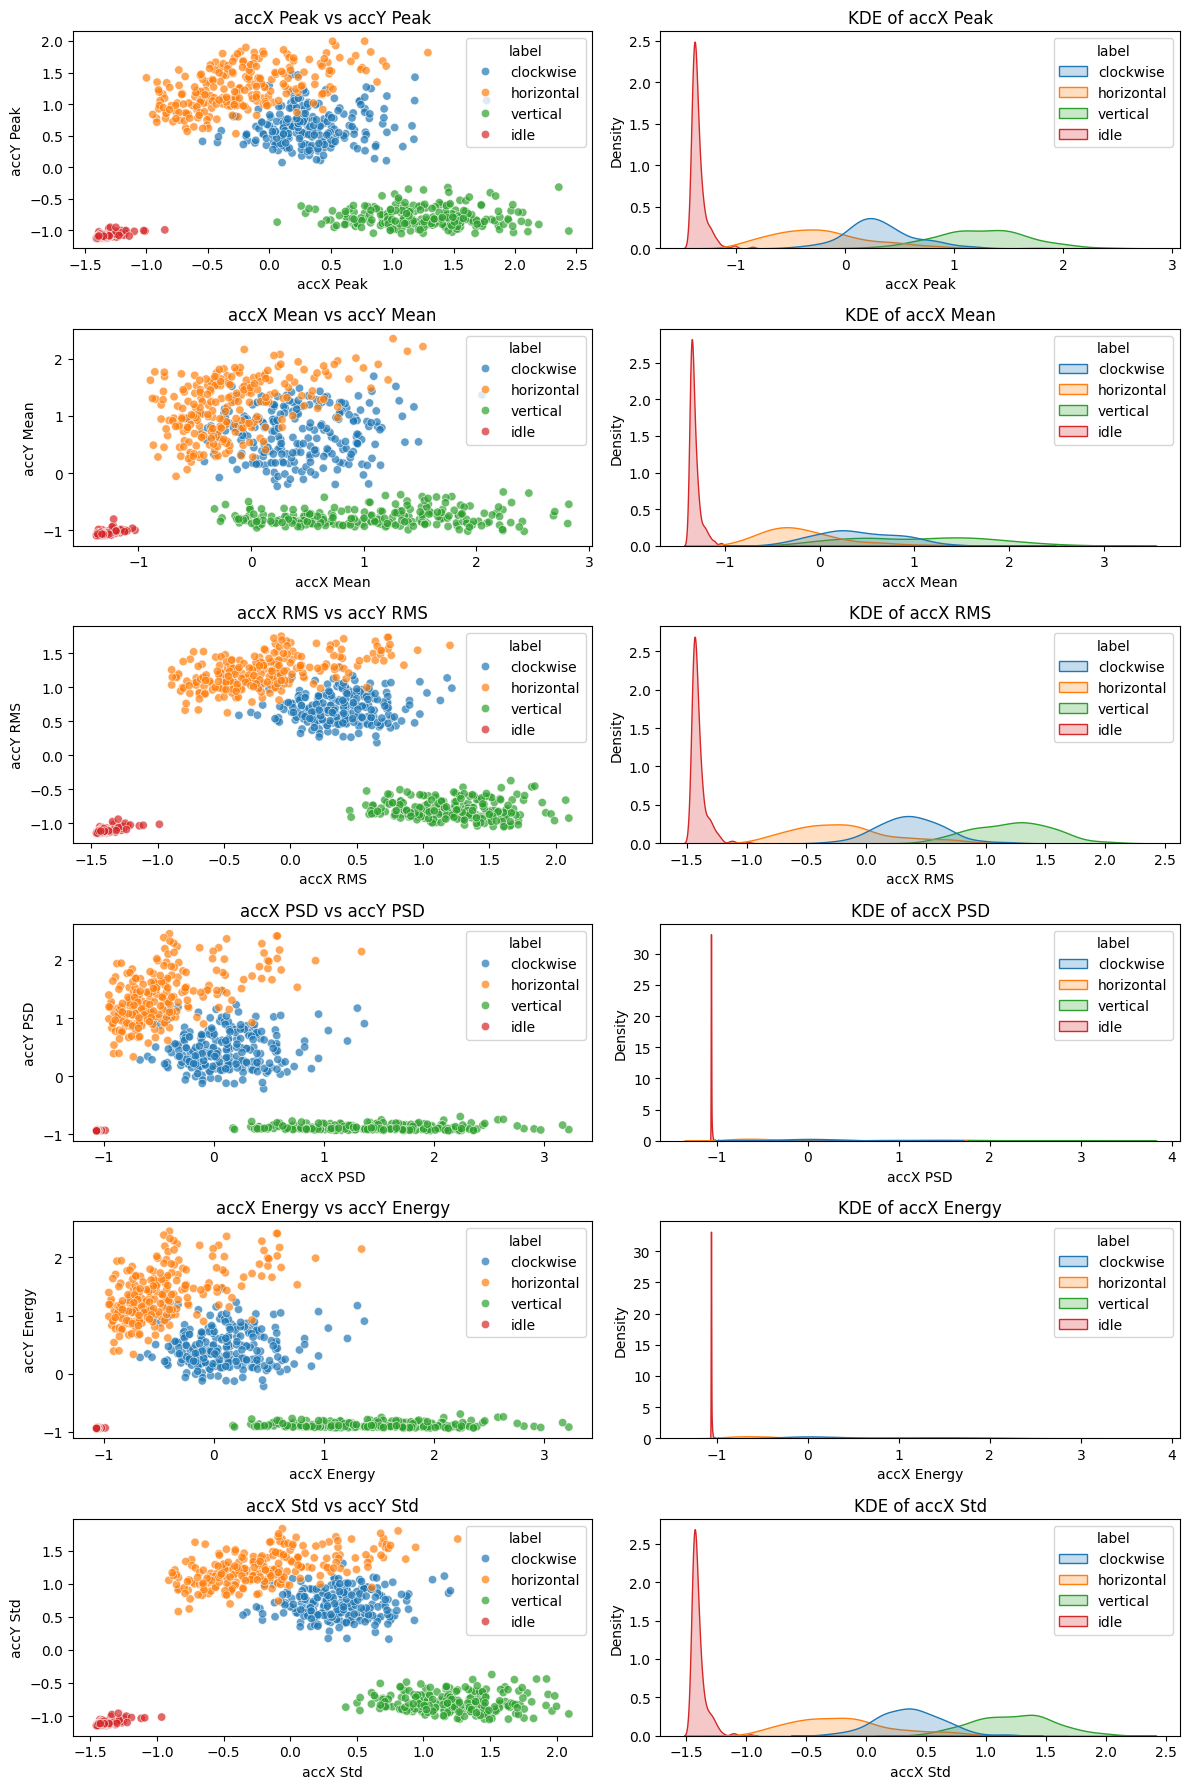

In [54]:
# Scatter plot of selected features with custom display labels
import seaborn as sns

fig, axs = plt.subplots(6, 2, figsize=(12, 18))

# Use internal DataFrame column names here
feature_pairs = [
    ('x_peak', 'y_peak'),
    ('x_mean', 'y_mean'),
    ('x_rms', 'y_rms'),
    ('x_psd', 'y_psd'),
    ('x_energy', 'y_energy'),
    ('x_std', 'y_std'),
]

# Human-readable labels shown on plots
feature_display = {
    'x_peak': 'accX Peak', 'y_peak': 'accY Peak', 'z_peak': 'accZ Peak',
    'x_mean': 'accX Mean', 'y_mean': 'accY Mean', 'z_mean': 'accZ Mean',
    'x_rms': 'accX RMS', 'y_rms': 'accY RMS', 'z_rms': 'accZ RMS',
    'x_psd': 'accX PSD', 'y_psd': 'accY PSD', 'z_psd': 'accZ PSD',
    'x_energy': 'accX Energy', 'y_energy': 'accY Energy', 'z_energy': 'accZ Energy',
    'x_std': 'accX Std', 'y_std': 'accY Std', 'z_std': 'accZ Std',
}

for i, (feat_x, feat_y) in enumerate(feature_pairs):
    sns.scatterplot(
        data=scaled_spectral_feature_df,
        x=feat_x,
        y=feat_y,
        hue='label',
        ax=axs[i, 0],
        alpha=0.7
    )
    axs[i, 0].set_title(f"{feature_display.get(feat_x, feat_x)} vs {feature_display.get(feat_y, feat_y)}")
    axs[i, 0].set_xlabel(feature_display.get(feat_x, feat_x))
    axs[i, 0].set_ylabel(feature_display.get(feat_y, feat_y))
    sns.move_legend(axs[i, 0], loc='upper right')

    sns.kdeplot(
        data=scaled_spectral_feature_df,
        x=feat_x,
        hue='label',
        ax=axs[i, 1],
        fill=True
    )
    axs[i, 1].set_title(f"KDE of {feature_display.get(feat_x, feat_x)}")
    axs[i, 1].set_xlabel(feature_display.get(feat_x, feat_x))
    sns.move_legend(axs[i, 1], loc='upper right')

plt.tight_layout()
plt.show()

# Splitting the Dataset into Training, Testing, and Validation Set
Splitting a dataset is a crucial step in machine learning to evaluate model performance and prevent overfitting. Typically, the data is divided into three sets:
- **Training Set**: Used to train the model.
- **Validation Set**: Used to tune hyperparameters and select the best model.
- **Testing Set**: Used to assess the final model performance.

A common approach is to first split the data into training and testing sets, then further split the training set into training and validation sets. This ensures that the validation and test sets remain unseen during training and hyperparameter tuning.

<img src="https://cdn.imweb.me/upload/S202105076e626e4618b27/0f0c2df8f341c.png" style="width:70%; height:auto;">

In [55]:
# Include Train test set split function from scikit-learn
from sklearn.model_selection import train_test_split

# Slit the dataset into features and labels
X = scaled_spectral_feature_df[feature_columns].values
y = scaled_spectral_feature_df['label']

# Import OneHotEncoder from sklearn
from sklearn.preprocessing import OneHotEncoder

# Create an instance of OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the target labels using OneHotEncoder
y_encoded = encoder.fit_transform(y.values.reshape(-1, 1))

# Split data set to training set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y_encoded, 
                                                    test_size=0.20, 
                                                    shuffle=True, 
                                                    random_state=43, 
                                                    stratify=y_encoded)

# Split the training set for validation (20% of training set) and training (80% of training set)
X_null, X_val, y_null, y_val = train_test_split(X_train, 
                                                y_train,
                                                test_size=0.20,
                                                shuffle=True,
                                                random_state=43,
                                                stratify=y_train)

# Create a dataframe that holds the dataset shape (number of samples and features) for training and testing sets
dataset_shape = pd.DataFrame({
    'Dataset': ['Dataset', 'Training Set', 'Testing Set', 'Validation Set'],
    'Samples': [X.shape[0], X_train.shape[0], X_test.shape[0], X_val.shape[0]],
    'Features': [X.shape[1], X_train.shape[1], X_test.shape[1], X_val.shape[1]],
    'Target Classes': [y_encoded.shape[1], y_train.shape[1], y_test.shape[1], y_val.shape[1]]
})

# Build Arduino class-label array in the same order as one-hot columns in y_encoded
class_labels = encoder.categories_[0].tolist()
class_count = len(class_labels)
labels_csv = ', '.join([f'"{label}"' for label in class_labels])

arduino_class_labels = (
    f'constexpr int CLASS_COUNT = {class_count};\n'
    f'const char* const CLASS_LABELS[CLASS_COUNT] = {{{labels_csv}}};'
)

print('Arduino class labels definition:')
print(arduino_class_labels)

# Optional: save to a reusable header file
with open('ClassLabels.h', 'w') as f:
    f.write('// Generated from HAR_model_training.ipynb\n')
    f.write(arduino_class_labels + '\n')

print('\nWrote ClassLabels.h')

# Display the training and test set shapes
dataset_shape.style.hide(axis='index')

Arduino class labels definition:
constexpr int CLASS_COUNT = 4;
const char* const CLASS_LABELS[CLASS_COUNT] = {"clockwise", "horizontal", "idle", "vertical"};

Wrote ClassLabels.h


Dataset,Samples,Features,Target Classes
Dataset,948,18,4
Training Set,758,18,4
Testing Set,190,18,4
Validation Set,152,18,4


# Train the Classifier Model Using Keras
Keras is a high-level neural networks API, written in Python and capable of running on top of TensorFlow, CNTK, or Theano. It was developed with a focus on enabling fast experimentation. Being able to go from idea to result with the least possible delay is key to doing good research.

### Installation

To install Keras, you can use `pip`. It is recommended to install it in a virtual environment.

```bash
pip install keras
pip install tensorflow
```

Make sure you have the necessary libraries installed to proceed with training the model.

In [63]:
# Import Keras API
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

# Create a sequential model
model = Sequential()

# Add input layer with the shape of the feature columns
model.add(Input(shape=(X_train.shape[1],)))
# Add first hidden layer with 16 neurons and relu activation function
model.add(Dense(16, activation='relu'))
# Add second hidden layer with 12 neurons and relu activation function
model.add(Dense(12, activation='relu'))
# Add dropout layer with 0.05 dropout rate to prevent overfitting
model.add(Dropout(0.05))
# Add third hidden layer with 8 neurons and relu activation function
model.add(Dense(8, activation='relu'))
# Add dropout layer with 0.01 dropout rate to prevent overfitting
model.add(Dropout(0.01))
# Add output layer with the number of classes and softmax activation function
model.add(Dense(y_train.shape[1], activation='softmax'))

# Compile the model with Adam optimizer, categorical crossentropy loss function, and accuracy metric
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with training data, validation data, 30 epochs, and batch size of 32
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3179 - loss: 1.1990 - val_accuracy: 0.4342 - val_loss: 1.0706
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5567 - loss: 1.0193 - val_accuracy: 0.7368 - val_loss: 0.9408
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6966 - loss: 0.8970 - val_accuracy: 0.7500 - val_loss: 0.8111
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7309 - loss: 0.7594 - val_accuracy: 0.7895 - val_loss: 0.6757
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8179 - loss: 0.6389 - val_accuracy: 0.8947 - val_loss: 0.5541
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9327 - loss: 0.5175 - val_accuracy: 0.9671 - val_loss: 0.4374
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9763 - loss: 0.4116 - val_accuracy: 1.0000 - val_loss: 0.3323
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9763 - loss: 0.3277 - val_accuracy: 1.0000 - val_loss

# Visualization of Keras Neural Network Training Process
Visualize Keras loss curves by plotting the `history.history` dictionary returned by `model.fit()` using Matplotlib. Key metrics to plot include training loss (`'loss'`) and validation loss (`'val_loss'`) against epochs to identify overfitting or underfitting. This provides a clear visualization of training progress and performance. After training a Keras model, use the history object to plot the loss. 

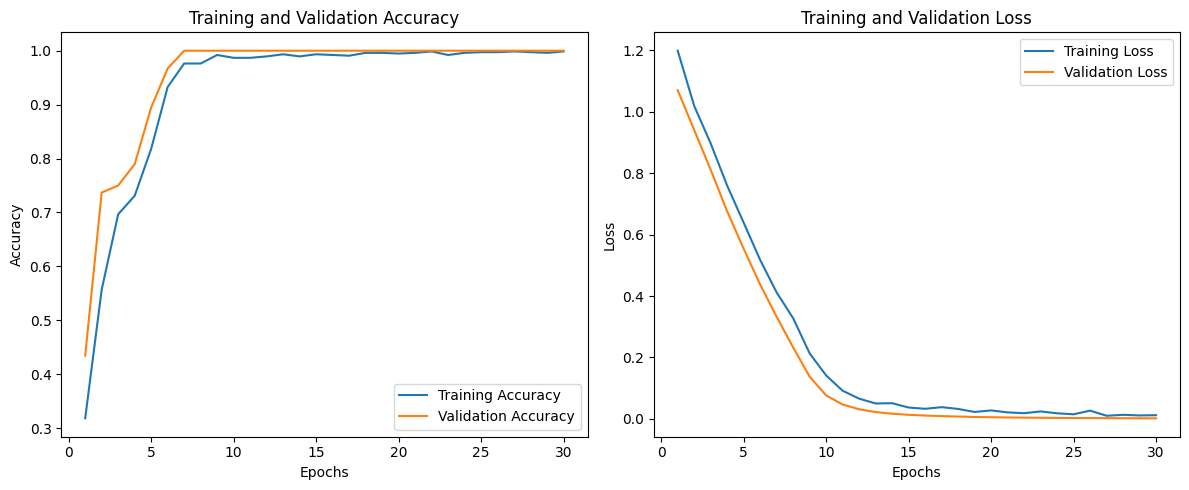

In [64]:
import matplotlib.pyplot as plt

# Compute for the training and validation accuracy from the training history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Compute for the training and validation loss from the training history
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# return epochs range for plotting
epochs_range = range(1, len(train_accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Performance of the Classifier Model
Keras classifier performance is evaluated by compiling models with metrics like accuracy, training with `model.fit()`, and evaluating on test data.

In [65]:
# Print the performance metrics such as accuracy, precision, recall, and F1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Perform prediction on the test set
predictions = model.predict(X_test)

# Convert one-hot encoded true labels and predicted probabilities to class indices
y_test_labels = encoder.inverse_transform(y_test)
y_pred_labels = encoder.inverse_transform(predictions)

# Create a dataframe to display the true labels and predicted labels
results_df = pd.DataFrame({
    'True Label': y_test_labels.flatten(),  
    'Predicted Label': y_pred_labels.flatten()
})

# Display 10 random samples of the true labels and predicted labels
results_df.sample(10).style.hide(axis='index')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


True Label,Predicted Label
clockwise,clockwise
vertical,vertical
idle,idle
clockwise,clockwise
clockwise,clockwise
idle,idle
idle,idle
clockwise,clockwise
vertical,vertical
idle,idle


In [66]:
# Create a dataframe for the model performance metrics
performance_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [f'{accuracy_score(y_test_labels, y_pred_labels) * 100.00:.2f}%',
              f'{precision_score(y_test_labels, y_pred_labels, average="weighted") * 100.00:.2f}%',
              f'{recall_score(y_test_labels, y_pred_labels, average="weighted") * 100.00:.2f}%',
              f'{f1_score(y_test_labels, y_pred_labels, average="weighted") * 100.00:.2f}%']
})

# Display the performance metrics
performance_metrics.style.hide(axis='index')

Metric,Score
Accuracy,100.00%
Precision,100.00%
Recall,100.00%
F1 Score,100.00%


In [67]:
# Evaluate the model on the training and test sets
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

# Create a dataframe to display the evaluation results
evaluation_results = pd.DataFrame({
    'Dataset': ['Training Set', 'Test Set'],
    'Loss': [f'{train_loss:.4f}', f'{test_loss:.4f}'],
    'Accuracy': [f'{train_accuracy * 100.00:.2f}%', f'{test_accuracy * 100.00:.2f}%']
})

# Display the evaluation results
evaluation_results.style.hide(axis='index')

Dataset,Loss,Accuracy
Training Set,0.0040,100.00%
Test Set,0.0030,100.00%


# Port the Classifier Model to C Code
## emlearn - Machine Learning for Tiny Embedded Systems
```emlearn``` is an open-source Python library that allows converting scikit-learn and Keras models to efficient C code. This makes it easy to deploy to any microcontroller with, while keeping Python-based workflow that is familiar to Machine Learning Engineers.

To install emlearn to convert models in Python, use ```pip install emlearn```

In [68]:
# Convert model using emlearn
import emlearn

# Convert the trained Neural Network model to C++ code using emlearn
sequencial_model_cgen = emlearn.convert(model, method='inline', dtype='int', return_type='classifier')

# Generate and save the C code to a header file
sequencial_model_c_code = sequencial_model_cgen.save(file='NeuralNetworkClassifier.h', name='NeuralNetworkClassifier')

# Display the model generated C code
print(sequencial_model_c_code)


#include <eml_net.h>
static const float NeuralNetworkClassifier_layer_0_biases[16] = { 0.090188f, 0.200905f, 0.078807f, 0.268493f, 0.028486f, 0.083108f, 0.097079f, -0.008591f, -0.006237f, 0.097309f, 0.105128f, 0.322979f, 0.283440f, 0.093412f, 0.004886f, 0.073564f };
static const float NeuralNetworkClassifier_layer_0_weights[288] = { -0.109758f, 0.308770f, 0.031717f, -0.170830f, 0.381644f, -0.193982f, -0.367613f, -0.269165f, -0.210107f, 0.347539f, -0.151138f, 0.248562f, 0.470210f, 0.142294f, 0.239030f, -0.048396f, -0.176882f, 0.428625f, -0.052775f, 0.441570f, 0.250720f, -0.325225f, 0.368268f, 0.138499f, 0.241026f, -0.265603f, -0.032994f, 0.161473f, 0.044436f, -0.427135f, -0.291799f, 0.145470f, 0.166770f, -0.217250f, -0.437493f, -0.205297f, 0.307684f, -0.203787f, -0.250281f, -0.331844f, 0.351381f, -0.283985f, 0.319238f, 0.097990f, -0.033633f, -0.373175f, -0.047219f, -0.245830f, 0.089823f, -0.313298f, -0.075488f, -0.110275f, 0.188312f, -0.101369f, -0.175908f, 0.372242f, 0.335581f, 0.2466